In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('loan_approval_data.csv')


df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')



In [34]:
df.sample(10)

,applicant_income,coapplicant_income,age,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,loan_amount,...,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,property_area_Semiurban,property_area_Urban,gender_Male,employer_category_Government,employer_category_MNC,employer_category_Private,employer_category_Unemployed
627,17183.000000,6527.000000,26,1,611.0,1,0.430000,9696.0,27195.000000,32876.000000,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
695,10852.571579,8927.000000,36,0,584.0,4,0.220000,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
32,12627.000000,5082.455789,51,2,689.0,3,0.400000,10524.0,34525.000000,35364.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
311,4491.000000,5082.455789,39,2,565.0,0,0.310000,19159.0,38362.000000,21754.000000,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
262,10852.571579,3972.000000,44,3,717.0,0,0.170000,17040.0,41628.000000,7060.000000,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
288,9206.000000,6924.000000,27,0,635.0,3,0.390000,15588.0,22553.000000,21425.000000,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
510,19640.000000,6236.000000,43,2,760.0,0,0.210000,9065.0,47358.000000,14733.000000,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
601,8881.000000,281.000000,49,0,637.0,0,0.200000,15522.0,38015.000000,34405.000000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
53,11692.000000,3850.000000,37,1,799.0,4,0.347263,11545.0,7494.000000,21942.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
595,3252.000000,956.000000,59,3,697.0,4,0.100000,10786.0,8437.000000,27365.000000,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


# Understanding the data

In [4]:


df.isnull().sum()

df.describe()
df.duplicated().sum()
df['loan_approved'].isnull().sum()
df['applicant_id'].duplicated().sum()

df.info()


# df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   applicant_id        950 non-null    float64
 1   applicant_income    950 non-null    float64
 2   coapplicant_income  950 non-null    float64
 3   employment_status   950 non-null    object 
 4   age                 950 non-null    float64
 5   marital_status      950 non-null    object 
 6   dependents          950 non-null    float64
 7   credit_score        950 non-null    float64
 8   existing_loans      950 non-null    float64
 9   dti_ratio           950 non-null    float64
 10  savings             950 non-null    float64
 11  collateral_value    950 non-null    float64
 12  loan_amount         950 non-null    float64
 13  loan_term           950 non-null    float64
 14  loan_purpose        950 non-null    object 
 15  property_area       950 non-null    object 
 16  educati

In [5]:
df = df.drop('applicant_id', axis=1)

# Handle Missing Value

In [6]:


numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [7]:
print(df.columns)

Index(['applicant_income', 'coapplicant_income', 'employment_status', 'age',
       'marital_status', 'dependents', 'credit_score', 'existing_loans',
       'dti_ratio', 'savings', 'collateral_value', 'loan_amount', 'loan_term',
       'loan_purpose', 'property_area', 'education_level', 'gender',
       'employer_category', 'loan_approved'],
      dtype='object')


In [8]:
# Simple imputer - cikit-learn class used to handle missing values in a dataset by replacing them with a specified statistical metric (like the mean, median, or mode).

from sklearn.impute import SimpleImputer

# fill numeric cols
num_imp = SimpleImputer(strategy='mean')
df[numeric_cols] = num_imp.fit_transform(df[numeric_cols])

# fill categorical cols

cat_imp = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [9]:

integer_cols = [
    "age",
    "dependents",
    "existing_loans",
    "loan_term"
]

df[integer_cols] = df[integer_cols].astype(int)

# EDA - exploatory data analysis

Text(0.5, 1.0, 'Loan approved or not')

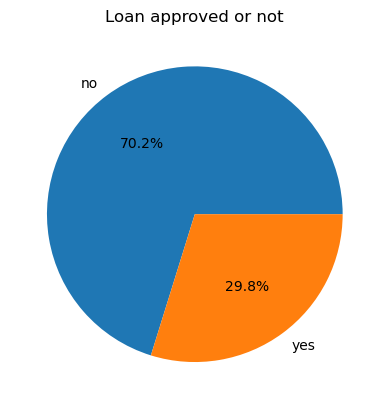

In [10]:
# balance of calsses (output)


df['loan_approved'].value_counts(normalize=True)   # to get % of distribution of yes and no

classes_counts = df['loan_approved'].value_counts()

plt.pie(classes_counts, labels=['no','yes'], autopct='%1.1f%%')
plt.title('Loan approved or not')

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

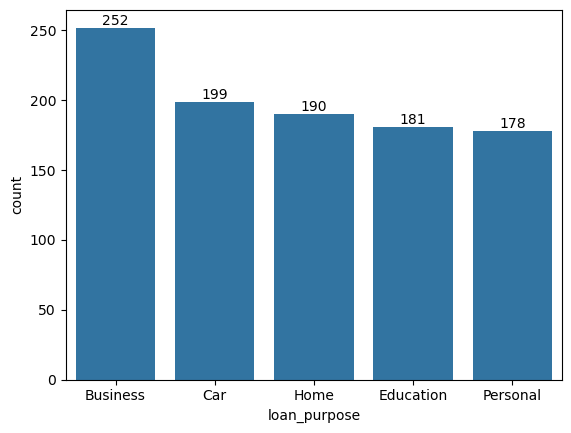

In [11]:
# edu_counts = df['education_level'].value_counts()

# ax = sns.barplot(edu_counts)
# ax.bar_label(ax.containers[0])

# gender_counts = df['gender'].value_counts()
# ax = sns.barplot(gender_counts)
# ax.bar_label(ax.containers[0])

# area_counts = df['property_area'].value_counts()
# ax = sns.barplot(area_counts)
# ax.bar_label(ax.containers[0])

# emp_status_counts = df['employment_status'].value_counts()
# ax = sns.barplot(emp_status_counts)
# ax.bar_label(ax.containers[0])

loan_purpose_counts = df['loan_purpose'].value_counts()
ax = sns.barplot(loan_purpose_counts)
ax.bar_label(ax.containers[0])

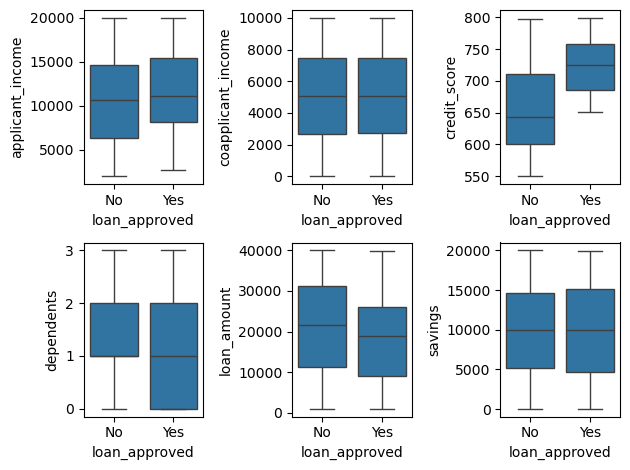

In [12]:
fig, axes = plt.subplots(2,3)

sns.boxplot(ax=axes[0,0], data=df, x='loan_approved', y='applicant_income')
sns.boxplot(ax=axes[0,1], data=df, x='loan_approved', y='coapplicant_income')
sns.boxplot(ax=axes[0,2], data=df, x='loan_approved', y='credit_score')
sns.boxplot(ax=axes[1,0], data=df, x='loan_approved', y='dependents')
sns.boxplot(ax=axes[1,1], data=df, x='loan_approved', y='loan_amount')
sns.boxplot(ax=axes[1,2], data=df, x='loan_approved', y='savings')
# sns.boxplot(ax=axes[0,0], data=df, x='loan_approved', y='loan_amount')

plt.tight_layout()

<Axes: xlabel='credit_score', ylabel='Count'>

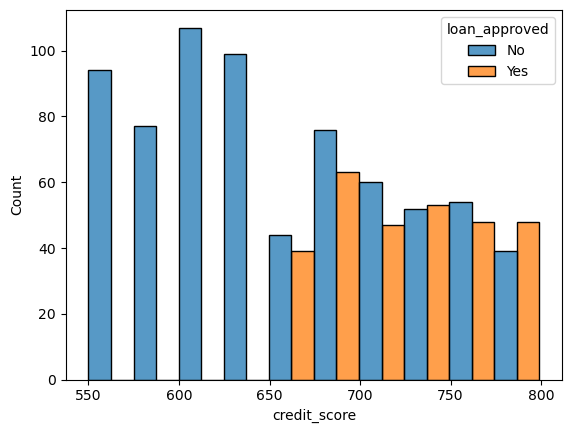

In [13]:
# Checking loan_approved with credit score

sns.histplot(
    data=df,
    x='credit_score',
    hue='loan_approved',
    bins=10,
    multiple='dodge'
)

<Axes: xlabel='applicant_income', ylabel='Count'>

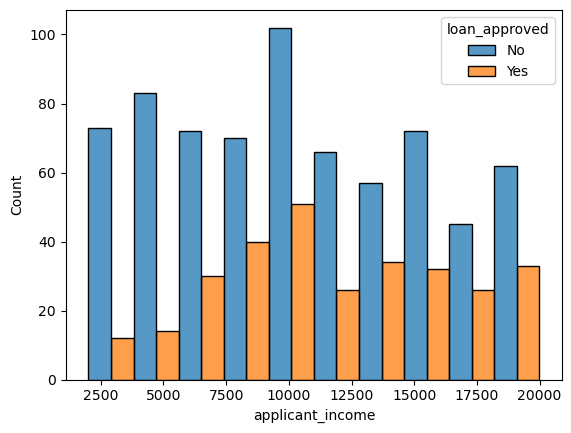

In [14]:
# Checking loan_approved with loan_amount

# sns.histplot(
#     data=df,
#     x='loan_amount',
#     hue='loan_approved',
#     bins=10,
#     multiple='dodge'
# )

# Checking loan_approved with loan_amount

sns.histplot(
    data=df,
    x='applicant_income',
    hue='loan_approved',
    bins=10,
    multiple='dodge'
)

# Enocding

In [15]:
# labelencoder - LabelEncoder is a preprocessing tool that converts categorical text labels into numerical integers (ranging from 0 to n_classes-1).It assigns a unique number to each unique category

# onehotencoder - OneHotEncoder is a preprocessing tool that converts categorical text labels into a series of binary columns (0s and 1s).

# labelencoder is used for ordinary data where order matters (like education, here high education means high val)
# onehotencoder is used for nominal data (means every value is equal like emplyment status or gender)

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

education_encoder = LabelEncoder()
loan_encoder = LabelEncoder()

df['education_level'] = education_encoder.fit_transform(df['education_level'])
df['loan_approved'] = loan_encoder.fit_transform(df['loan_approved'])


In [16]:
df.columns

Index(['applicant_income', 'coapplicant_income', 'employment_status', 'age',
       'marital_status', 'dependents', 'credit_score', 'existing_loans',
       'dti_ratio', 'savings', 'collateral_value', 'loan_amount', 'loan_term',
       'loan_purpose', 'property_area', 'education_level', 'gender',
       'employer_category', 'loan_approved'],
      dtype='object')

In [17]:
# cols for onehotencoder
cols = ['employment_status','marital_status','loan_purpose','property_area','gender','employer_category']

ohe = OneHotEncoder(drop='first',sparse_output=False, handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])    # it returns a 2D arr 

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)   # so we convert it into df

df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [18]:
df.head()

,applicant_income,coapplicant_income,age,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,loan_amount,...,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,property_area_Semiurban,property_area_Urban,gender_Male,employer_category_Government,employer_category_MNC,employer_category_Private,employer_category_Unemployed
0,17795.0,1387.0,51,0,637.0,4,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46,3,621.0,2,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25,2,674.0,4,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40,2,579.0,3,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31,2,721.0,1,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

In [19]:
# A correlation heatmap is a visual representation of a correlation matrix, used to show the strength and direction of linear relationships between numerical variables in a dataset.

# It uses a color scale to represent values between -1 and +1:+1 

# (Dark/Warm color): Perfect positive correlation (as one variable goes up, the other goes up).
# 0 (Light/Neutral color): No linear correlation at all.
# -1 (Dark/Cool color): Perfect negative correlation (as one variable goes up, the other goes down).

# +ve corr means when x1 inc then x2 also inc
# -ve corr means when x1 inc then x2 dec


# Benifits

# 1. get quick insight
# 2. data exploration
# 3. helps in preprocessing

<Axes: >

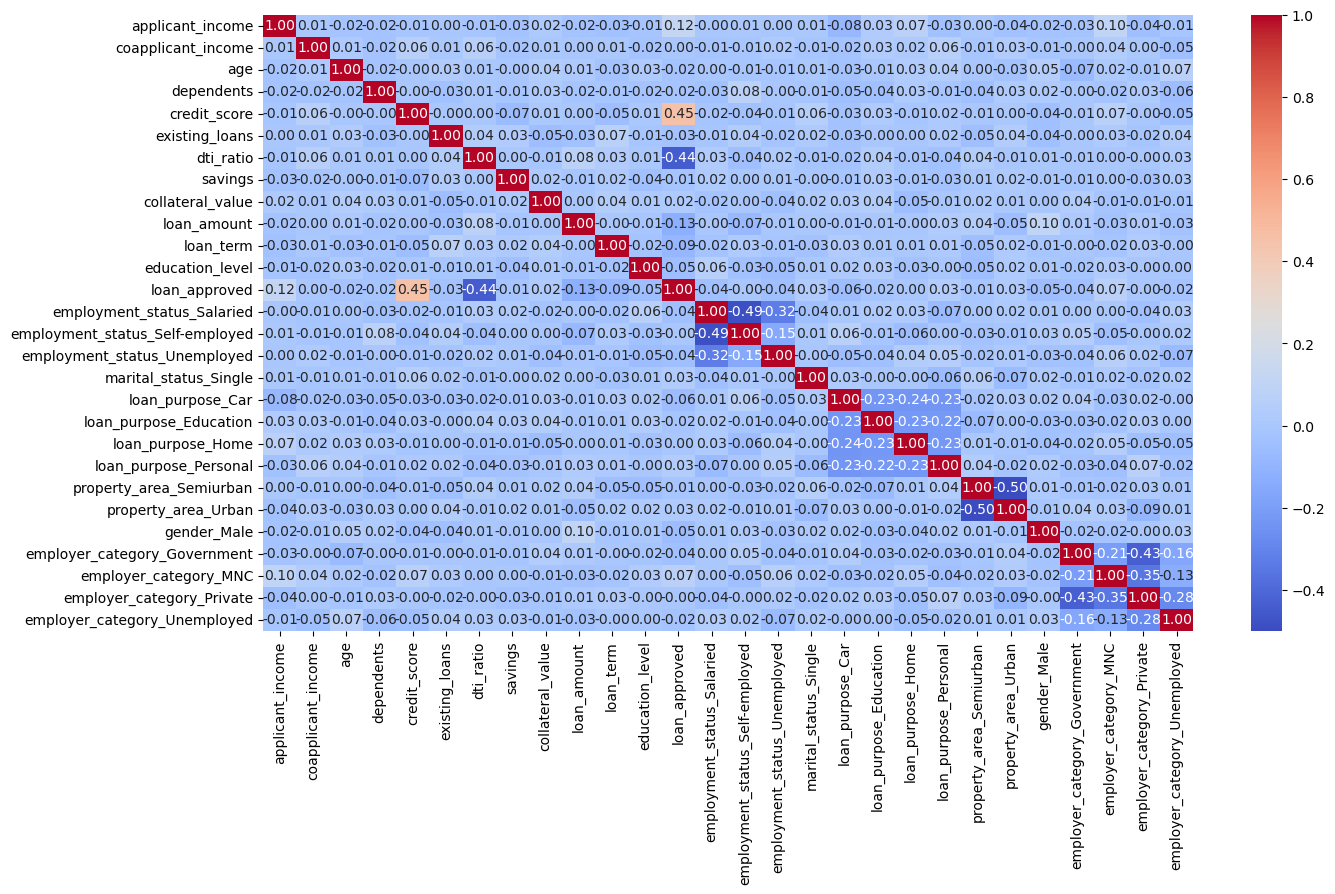

In [20]:
numeric_cols = df.select_dtypes(include=['number'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(15,8))
plt.tight_layout()
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

In [21]:
# corr_matrix

numeric_cols.corr()['loan_approved'].sort_values(ascending=False)

loan_approved                      1.000000
credit_score                       0.451175
applicant_income                   0.119796
employer_category_MNC              0.069049
loan_purpose_Personal              0.034043
marital_status_Single              0.030182
property_area_Urban                0.025963
collateral_value                   0.021868
coapplicant_income                 0.004230
loan_purpose_Home                  0.002118
employment_status_Self-employed   -0.001337
employer_category_Private         -0.003347
property_area_Semiurban           -0.012967
savings                           -0.013437
loan_purpose_Education            -0.016684
dependents                        -0.018999
employer_category_Unemployed      -0.021468
age                               -0.021967
existing_loans                    -0.028553
employer_category_Government      -0.039187
employment_status_Salaried        -0.041428
employment_status_Unemployed      -0.044464
education_level                 

# Train test split + Feature Scaling

In [22]:
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

In [23]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: loan_approved, dtype: int64

In [24]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate

In [26]:
# Logistic regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, accuracy_score, recall_score, f1_score, confusion_matrix

log_model = LogisticRegression()

log_model.fit(X_train_scaled,y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
import joblib

joblib.dump(log_model, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(education_encoder, "education_encoder.pkl")
joblib.dump(loan_encoder, "loan_encoder.pkl")
joblib.dump(num_imp, "num_imputer.pkl")
joblib.dump(cat_imp, "cat_imputer.pkl")

['cat_imputer.pkl']

In [28]:
y_pred = log_model.predict(X_test_scaled)

In [29]:
# Evaluation - Here precision matter(FP) a lot bcz in problem statement we have to reduce the approve the loan to risky people and after that recall(FN) means don't reject good customers  

print('Precision:', precision_score(y_test,y_pred))
print('Recall:', recall_score(y_test,y_pred))
print('Accuracy:', accuracy_score(y_test,y_pred))
print('F1 score:', f1_score(y_test,y_pred))
print('CM:', confusion_matrix(y_test,y_pred))

Precision: 0.7833333333333333
Recall: 0.7704918032786885
Accuracy: 0.865
F1 score: 0.7768595041322314
CM: [[126  13]
 [ 14  47]]


In [30]:
# KNN - it peroforms poor incase of so much features 

from sklearn.neighbors import KNeighborsClassifier

kNN_model = KNeighborsClassifier(n_neighbors=9)

kNN_model.fit(X_train_scaled,y_train)

y_pred = kNN_model.predict(X_test_scaled)

In [31]:
print('Precision:', precision_score(y_test,y_pred))
print('Recall:', recall_score(y_test,y_pred))
print('Accuracy:', accuracy_score(y_test,y_pred))
print('F1 score:', f1_score(y_test,y_pred))
print('CM:', confusion_matrix(y_test,y_pred))

Precision: 0.6428571428571429
Recall: 0.4426229508196721
Accuracy: 0.755
F1 score: 0.5242718446601942
CM: [[124  15]
 [ 34  27]]


In [32]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

In [33]:
print('Precision:', precision_score(y_test,y_pred))
print('Recall:', recall_score(y_test,y_pred))
print('Accuracy:', accuracy_score(y_test,y_pred))
print('F1 score:', f1_score(y_test,y_pred))
print('CM:', confusion_matrix(y_test,y_pred))

Precision: 0.8035714285714286
Recall: 0.7377049180327869
Accuracy: 0.865
F1 score: 0.7692307692307693
CM: [[128  11]
 [ 16  45]]
